
$$
\newcommand{\mbf}{\mathbf}
\newcommand{\lb}{{\langle}}
\newcommand{\rb}{{\rangle}}
\def\Ham{\hat{H}}
$$
$$
\newcommand{\mc}{\mathcal}
$$
The band structure of a material is particularly important for describing the macroscopic electronic properties of a periodic system, and the periodic translational symmetry is responsible for the existence of these energy bands. 

If we assume the \emph{nearly-free electron} regime: $\hat{H} = \hat{H}_0 + V$, with
$\hat{H}_0$ being the Hamiltonian of the free particle. For a free particle, the energy varies continuously as
$$
\begin{equation}
  E_0(\mbf k)=\frac{\hbar^2|\mbf k|^2}{2m}.
\end{equation}
$$
In a crystal, the electron also feels a periodic potential:
$$
\begin{equation}
  H=H_0+V,
  \qquad
  V(\mbf r+\mbf R)=V(\mbf r).
\end{equation}
$$


and the lattice-periodic potential $V(\mbf r + \mbf R)=V(\mbf r)$ for all
$\mbf R \in \mc{L}_B$, then for electrons in such a weak periodic structure, we can expand 
$$
\begin{equation}
  V(\mbf r)=\sum_{\mbf G} V_{\mbf G} e^{i \mbf G \cdot \mbf r}.  
\end{equation}
$$
The reason for which is beyond the scope of this paper. This expansion shows that the periodic potential couples plane waves whose wavevectors differ by reciprocal lattice vectors.


The most important place where this coupling matters is a Brillouin-zone boundary. There, two free-particle states $|\mbf k\rangle$ and $|\mbf k-\mbf G\rangle$ may have the same unperturbed energy:
$$
\begin{equation}
  E_0(\mbf k)=E_0(\mbf k-\mbf G).
\end{equation}
$$
Near such a boundary, the essential physics is captured by the two-dimensional subspace spanned by these two states. In this basis, the Hamiltonian takes the form
$$
\begin{equation}
  \hat{H} =
  \begin{pmatrix}
    E_0(\mbf k) + V_0 & V_{\mbf G} \\
    V_{\mbf G}^*      & E_0(\mbf k - \mbf G) + V_0
  \end{pmatrix}.
\end{equation}
$$
Note it is not diagonal.

At the Bragg plane $E_0(\mbf k)=E_0(\mbf k - \mbf G)$, the eigenstates are the symmetry-adapted combinations of the two plane waves:
Hamiltonian
$$
\begin{equation}
  |\pm\rb 
  = \frac{1}{\sqrt2} \big(\mbf k \pm e^{i\varphi} (\mbf k - \mbf G)\big),
  \quad \text{where }V_{\mbf G} = |V_{\mbf G }|e^{i\varphi},
\end{equation}
$$
and they have energies
$$
\begin{equation}
  E_\pm = E_0(\mbf k) + V_0 \pm |V_{\mbf G }|. 
\end{equation}
$$
Hence, a gap of size $\Delta E = 2|V_G|$ opens at the zone boundary. In real space (especially in 1D), these two combinations are essentially 
$\cos((\mbf k - \frac 1 2 \mbf G)\cdot \mbf r)$ 
and 
$\sin((\mbf k - \frac 1 2 \mbf G)\cdot \mbf r)$ 
standing-wave patterns, so one places more weight on lattice sites where $V$ is low and the other on sites where $V$ is high, explaining the energy splitting without any further computation.


In addition, at the Brillouin-zone boundary we have $k=\pm \pi/a$, the phase is $e^{ika}=-1$, so translation by one cell flips sign. Thus, modes at the zone edge are therefore standing-wave-like objects pinned by the discrete symmetry. 

At the Bragg plane, we have $|k| = |k-G|$, where $G$ is a reciprocal lattice vector, implying $E_0(k)=E_0(k-G)$, so the two plane-wave states $|k\rb$ and $|k-G\rb$ are degenerate. 




zone-edge gap = 1.200
first-order prediction 2|V_G| = 1.200


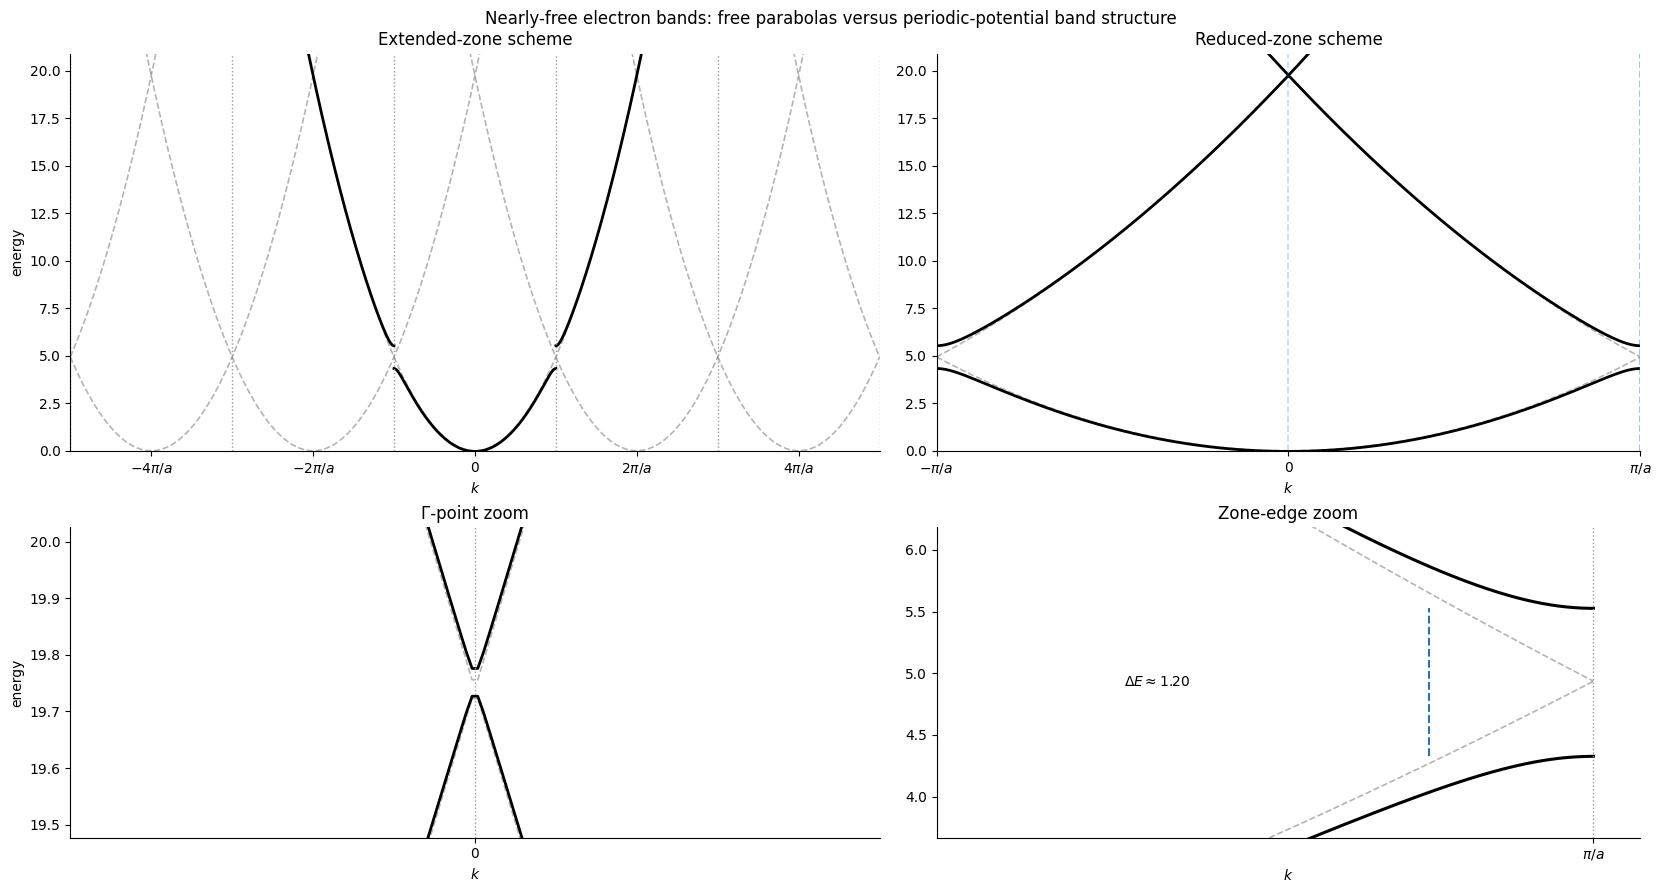

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.axes import Axes
import numpy as onp

_project_root = Path.cwd()
if _project_root.name == "notebooks":
  _project_root = _project_root.parent
if str(_project_root) not in sys.path:
  sys.path.insert(0, str(_project_root))

from examples.lattice_plots import plot_nearly_free_electron_schemes
from examples.per_sym import nearly_free_electron_reduced_bands_1d

a = 1.0
V_G = 0.60
V_2G = 0.0
n_shells = 3

# This is still a toy nearly-free-electron model; the slightly larger V_G
# and small V_2G just make the gap and upper-band rounding visible.
fig = plot_nearly_free_electron_schemes(
  a=a,
  V_G=V_G,
  V_2G=V_2G,
  hbar=1.0,
  m=1.0,
  n_shells=n_shells,
  n_bands=4,
  zone_count=2,
)

kb = onp.pi / a
_, bands, _ = nearly_free_electron_reduced_bands_1d(
  onp.array([kb]), V_G=V_G, V_2G=V_2G, a=a, hbar=1.0, m=1.0, n_shells=n_shells,
)
gap = bands[1, 0] - bands[0, 0]
print(f"zone-edge gap = {gap:.3f}")
print(f"first-order prediction 2|V_G| = {2 * abs(V_G):.3f}")
plt.show()
fig.savefig("brillouin_first_order", dpi=300)


In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
from plotting_utils import save_path
from examples.comps_plots import make_prism_dispersion_figure

fig = make_prism_dispersion_figure()
save_path(fig, "prism_dispersion.png", close=False)
plt.close(fig)

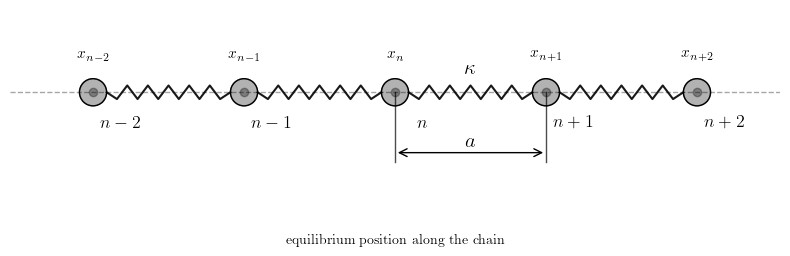

In [2]:
import numpy as onp
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch
import matplotlib as mpl

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],  # or your document font
    "text.latex.preamble": r"\usepackage{amsmath}",
})


def spring_points(x0, x1, y=0.0, amp=0.08, coils=7, margin=0.16):
  """
  Build a zig-zag spring between x0 and x1.
  margin keeps the spring from entering the mass circles.
  """
  xs = onp.linspace(x0 + margin, x1 - margin, 2 * coils + 1)
  ys = onp.zeros_like(xs) + y

  for i in range(1, len(xs) - 1):
    ys[i] += amp * ((-1) ** i)

  return xs, ys


def plot_1d_chain(a=1.0, n_min=-2, n_max=2, save_path=None):
  fig, ax = plt.subplots(figsize=(8, 2.6))

  ns = onp.arange(n_min, n_max + 1)
  xs = ns * a
  ax.scatter(xs, onp.zeros_like(xs), color='k', alpha=0.3)

  # oscillations = onp.eye((n_max + 1 - n_min)) + onp.diag(onp.array(onp.sin(2 * onp.pi * ns / (n_max - n_min))))
  # print(oscillations)
  oscillations =  0.25 * onp.array(onp.sin(2 * onp.pi * xs / (n_max - n_min)))
  # xs = xs + oscillations

  mass_radius = 0.09 * a

  # Draw equilibrium axis
  ax.axhline(0, linewidth=1, alpha=0.35, color='k', linestyle='--')

  # Draw springs
  for x0, x1 in zip(xs[:-1], xs[1:]):
    sx, sy = spring_points(
      x0,
      x1,
      y=0.0,
      amp=0.045 * a,
      coils=6,
      margin=mass_radius,
    )
    ax.plot(sx, sy, linewidth=1.5, color='k', alpha=0.9)

  # Draw masses and labels
  
  for n, x in zip(ns, xs):
    circ = Circle((x, 0), radius=mass_radius, fill=False, linewidth=1)
    ax.add_patch(circ)
    circ = Circle((x, 0), radius=mass_radius, fill=True, color='k', alpha=0.3)
    ax.add_patch(circ)

    # Site label under each mass
    if n == 0:
      label = r"$n$"
    elif n > 0:
      label = rf"$n+{n}$"
    else:
      label = rf"$n{n}$"

    ax.text(x + 2 * mass_radius, -0.2 * a, label, ha="center", va="center", fontsize=13)

    # Equilibrium position label
    ax.text(x, 0.23 * a, rf"$x_{{{label[1:-1]}}}$", ha="center", fontsize=11)

  # Show lattice spacing a between n and n+1
  x_left = 0
  x_right = a
  y_arrow = -0.4 * a

  arrow = FancyArrowPatch(
    (x_left, y_arrow),
    (x_right, y_arrow),
    arrowstyle="<->",
    mutation_scale=14,
    linewidth=1,
  )
  ax.add_patch(arrow)

  ax.text(0.5 * a, y_arrow + 0.08 * a, r"$a$", ha="center", va="center", fontsize=15)
  ax.text(0.5 * a,  0.16 * a, r"$\kappa$", ha="center", va="center", fontsize=15)
  # ax.text(0.5 * a, y_arrow + (0.08 - 0.24) * a, r"$u_{n+1} - u_n$", ha="center", va="center", fontsize=12)

  # Small guide lines showing endpoints of spacing a
  ax.plot([x_left, x_left], [y_arrow - 0.06 * a, 0],  linewidth=1, color='k', alpha=0.7)
  ax.plot([x_right, x_right], [y_arrow - 0.06 * a, 0],  linewidth=1, color='k', alpha=0.7)
  # ax.plot([xs[3], xs[3]], [y_arrow - 0.28 * a, 0],  linewidth=1, color='k', alpha=0.7)

  u_arrow = FancyArrowPatch(
    (x_left, y_arrow - 0.24),
    (xs[3], y_arrow - 0.24),
    arrowstyle="<->",
    mutation_scale=14,
    linewidth=1,
  )
  # ax.add_patch(u_arrow)


  ax.set(
    xlim=((n_min - 0.55) * a, (n_max + 0.55) * a),
    ylim=(-0.9 * a, 0.55 * a),
    aspect="equal",
    xlabel=r"equilibrium position along the chain",
    yticks=[],
    xticks=[],
  )

  ax.spines["left"].set_visible(False)
  ax.spines["right"].set_visible(False)
  ax.spines["top"].set_visible(False)
  ax.spines["bottom"].set_visible(False)

  fig.tight_layout()

  if save_path is not None:
    fig.savefig(save_path, bbox_inches="tight", dpi=300)

  return fig, ax


fig, ax = plot_1d_chain(a=1.0, n_min=-2, n_max=2, save_path="monatomic_chain.pdf")
plt.show()

In [18]:
from matplotlib.axes import Axes

def plot_aux_bond_potential_and_forces(
    ax: Axes,
    x_eq: onp.ndarray,
    x_disp: onp.ndarray,
    u: onp.ndarray,
    a: float,
    kappa: float=1.0,
):
  y_pot = 0.82 * a
  y_force = -0.12 * a

  # Bond extensions and harmonic bond energies.
  delta = u[2:] - u[1:-1]
  V_bond1 = 0.5 * kappa * delta**2

  delta2 = u[1:-1] - u[:-2]
  V_bond2 = 0.5 * kappa * delta2**2

  V_bond = V_bond1 + V_bond2
  # Force on each displayed mass. Endpoints are artificial in the finite drawing,
  # so only plot interior forces.
  F = onp.zeros_like(u)
  F[1:-1] = kappa * (u[2:] - 2 * u[1:-1] + u[:-2])

  bond_mid = 0.5 * (x_eq[:-1] + x_eq[1:])

  dmax = max(onp.max(onp.abs(delta)), 1e-12)
  vmax = max(onp.max(V_bond), 1e-12)
  fmax = max(onp.max(onp.abs(F[1:-1])), 1e-12)

  # Baseline for the bond-energy row.
  ax.hlines(
    y_pot,
    x_eq[0] - 0.25 * a,
    x_eq[-1] + 0.25 * a,
    linewidth=0.8,
    color="k",
    alpha=0.25,
    linestyle="--",
  )

  # Draw a small local harmonic potential over each bond.
  # The horizontal coordinate in each little parabola is NOT physical x.
  # It represents the local bond extension delta_n.
  s = onp.linspace(-1.0, 1.0, 80)

  for mid, d, Vn in zip(bond_mid, delta, V_bond):
    x_curve = mid + 0.23 * a * s
    y_curve = y_pot + 0.20 * a * s**2

    ax.plot(x_curve, y_curve, linewidth=0.8, color="k", alpha=0.35)

    x_dot = mid + 0.23 * a * d / dmax
    y_dot = y_pot + 0.20 * a * (d / dmax)**2

    ax.scatter([x_dot], [y_dot], s=14, color="k", zorder=5)

    # Optional vertical bar showing actual energy stored in that bond.
    ax.plot(
      [mid, mid],
      [y_pot - 0.08 * a, y_pot - 0.08 * a + 0.25 * a * Vn / vmax],
      linewidth=1.2,
      color="k",
      alpha=0.55,
    )

  ax.text(
    x_eq[0] - 0.55 * a,
    y_pot + 0.18 * a,
    r"$V_{n,n+1}=\frac{\kappa}{2}(u_{n+1}-u_n)^2$",
    ha="left",
    va="center",
    fontsize=10,
  )

  # Force arrows on the masses.
  for x, Fn in zip(x_disp[1:-1], F[1:-1]):
    if abs(Fn) < 1e-12:
      continue

    dx = 0.28 * a * Fn / fmax

    arrow = FancyArrowPatch(
      (x, y_force),
      (x + dx, y_force),
      arrowstyle="->",
      mutation_scale=9,
      linewidth=0.9,
      color="k",
      alpha=0.8,
    )
    ax.add_patch(arrow)

  ax.text(
    x_eq[0] - 0.55 * a,
    y_force,
    r"$F_n=\kappa(u_{n+1}-2u_n+u_{n-1})$",
    ha="left",
    va="center",
    fontsize=10,
  )

In [50]:
from matplotlib.axes import Axes

def plot_aux_bond_energy(
    ax: Axes,
    x_eq: onp.ndarray,
    u: onp.ndarray,
    *,
    a: float = 1.0,
    kappa: float = 1.0,
    y_offset: float = 0.78,
    height: float = 0.22,
):
  du = onp.diff(u)
  V_bond = 0.5 * kappa * du**2
  x_mid = 0.5 * (x_eq[:-1] + x_eq[1:])

  scale = onp.max(V_bond)
  if scale < 1e-12:
    scale = 1.0

  y = y_offset * a + height * a * V_bond / scale

  ax.hlines(
    y_offset * a,
    x_eq[0] - 0.1 * a,
    x_eq[-1] + 0.1 * a,
    linewidth=1.0,
    alpha=0.35,
    color="k",
    linestyle="--",
  )

  ax.vlines(x_mid, y_offset * a, y, linewidth=0.8, alpha=0.45, color="k")
  ax.plot(x_mid, y, linewidth=1.0, color="k", alpha=0.75)
  ax.scatter(x_mid, y, s=18, color="k")

  ax.text(
    x_eq[0] - 0.55 * a,
    y_offset * a,
    r"$V=0$",
    ha="left",
    va="center",
    fontsize=10,
  )

  ax.text(
    x_eq[0] - 0.55 * a,
    (y_offset + height) * a,
    r"$V_{n,n+1}$",
    ha="left",
    va="center",
    fontsize=10,
  )


def plot_aux_force_values(
    ax: Axes,
    x_eq: onp.ndarray,
    u: onp.ndarray,
    *,
    a: float = 1.0,
    kappa: float = 1.0,
    y_offset: float = 1.12,
    height: float = 0.16,
):
  F = kappa * (onp.roll(u, -1) - 2 * u + onp.roll(u, 1))

  # Avoid fake endpoint forces caused by finite plotting window.
  F_plot = F[1:-1]
  x_plot = x_eq[1:-1]

  scale = onp.max(onp.abs(F_plot))
  if scale < 1e-12:
    scale = 1.0

  y = y_offset * a + height * a * F_plot / scale

  ax.hlines(
    y_offset * a,
    x_eq[0] - 0.1 * a,
    x_eq[-1] + 0.1 * a,
    linewidth=1.0,
    alpha=0.35,
    color="k",
    linestyle="--",
  )

  ax.plot(x_plot, y, linewidth=1.0, color="k", alpha=0.75)
  ax.scatter(x_plot, y, s=18, color="k")

  for x0, y0 in zip(x_plot, y):
    ax.plot([x0, x0], [y_offset * a, y0], linewidth=0.8, alpha=0.45, color="k")

  ax.text(
    x_eq[0] - 0.55 * a,
    y_offset * a,
    r"$F=0$",
    ha="left",
    va="center",
    fontsize=10,
  )

  ax.text(
    x_eq[0] - 0.55 * a,
    (y_offset + height) * a,
    r"$F_n$",
    ha="left",
    va="center",
    fontsize=10,
  )

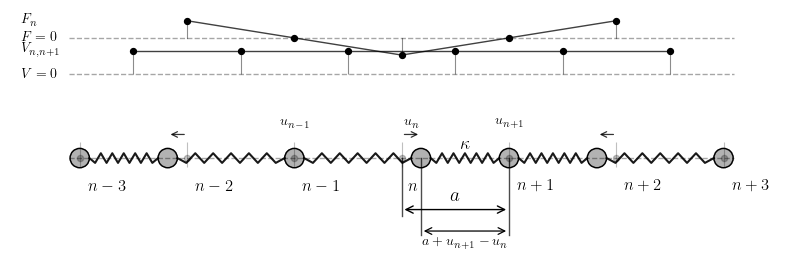

In [ ]:
import numpy as onp
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch, Rectangle
import matplotlib as mpl

mpl.rcParams.update({
  "text.usetex": True,
  "font.family": "serif",
  "font.serif": ["Computer Modern Roman"],
  "text.latex.preamble": r"\usepackage{amsmath}",
})


def spring_points(x0, x1, y=0.0, amp=0.045, coils=7, margin=0.09):
  xs = onp.linspace(x0 + margin, x1 - margin, 2 * coils + 1)
  ys = onp.zeros_like(xs) + y

  for i in range(1, len(xs) - 1):
    ys[i] += amp * ((-1) ** i)

  return xs, ys


def site_label(offset):
  if offset == 0:
    return r"$n$"
  if offset > 0:
    return rf"$n+{offset}$"
  return rf"$n{offset}$"


def plot_lattice_1d(ax: Axes, x_eq: onp.ndarray, xmin, xmax, y_offset: float=0, atom_alpha: float=0.22):
  # Equilibrium axis and equilibrium mass positions.
  ax.hlines(y_offset, xmin, xmax, linewidth=1.0, alpha=0.35, color="k", linestyle="--")
  ax.scatter(x_eq, onp.full(x_eq.shape, y_offset), color="k", alpha=atom_alpha, s=20)

def plot_aux_disp_amplitude(ax: Axes, n_min, n_max, A, k, omega, t, x_eq, u, i0):
  # ------------------------------------------------------------
  # Auxiliary vertical plot of displacement amplitude u_n(t)
  # ------------------------------------------------------------
  y_offset = 0.8 * a

  x_dense = onp.linspace((n_min - 0.1) * a, (n_max + 0.1) * a, 500)
  u_dense = A * a * onp.cos(k * x_dense - omega * t)

  # Continuous sinusoidal guide
  ax.plot(x_dense, y_offset + u_dense, linewidth=1.0, color='k', alpha=0.4)
  plot_lattice_1d(ax, x_eq, (n_min - 0.1) * a, (n_max + 0.1) * a, y_offset)

  # Vertical guides and site markers
  for x0, un in zip(x_eq, u):
    ax.plot([x0, x0], [y_offset, y_offset + un], linewidth=0.8, alpha=0.5, color='k')
    ax.scatter([x0], [y_offset + un], s=22, color='k')

  # Amplitude baseline label
  ax.text((n_min - 0.55) * a, y_offset, r"$u=0$", ha="left", va="center", fontsize=11)
  ax.text((n_min - 0.55) * a, y_offset + 0.24 * a, r"$u(x,t)$", ha="left", va="center", fontsize=11)
  # Optional amplitude label on one point
  ax.text(x_eq[i0], y_offset + u[i0] + 0.12 * a, r"$u_n(t)$", ha="center", fontsize=11)


def plot_aux_potential(ax: Axes, n_min, n_max, A, k, omega, t, x_eq, u):
  y_offset = 0.8 * a
  x_dense = onp.linspace(-a, a, 500)
  u_dense = A * a * onp.cos(k * x_dense - omega * t)
  plot_lattice_1d(ax, x_eq, (n_min - 0.1) * a, (n_max + 0.1) * a, y_offset)
  for x in x_eq:
    Vu = 1/2 * (onp.roll(u, 1) - u) ** 2
    # Vx = 1/2 * x_dense**2
    ax.plot(x + x_dense, y_offset + Vu, linewidth=1.0, color='k', alpha=0.4)



def plot_normal_mode_chain(
    a=1.0,
    n_min=-3,
    n_max=3,
    A=0.18,
    k=onp.pi / 2,
    omega=1.0,
    t=0.0,
):
  fig, ax = plt.subplots(figsize=(8.5, 2.8))

  ns = onp.arange(n_min, n_max + 1)

  # Equilibrium positions and displacements kept separate.
  x_eq = ns * a
  u = A * a * onp.cos(k * x_eq - omega * t)
  x_disp = x_eq + u

  mass_radius = 0.09 * a

  # Equilibrium axis and equilibrium mass positions.
  plot_lattice_1d(ax, x_eq, (n_min - 0.1) * a, (n_max + 0.1) * a)


  # Draw springs between displaced masses.
  for x0, x1 in zip(x_disp[:-1], x_disp[1:]):
    sx, sy = spring_points(
      x0,
      x1,
      y=0.0,
      amp=0.045 * a,
      coils=6,
      margin=mass_radius,
    )
    ax.plot(sx, sy, linewidth=1.5, color="k", alpha=0.9)

  # Draw masses, displacement arrows, and labels.
  for i, (offset, x0, x1, un) in enumerate(zip(ns, x_eq, x_disp, u)):
    # Dashed vertical guide at equilibrium site.
    ax.vlines(x0, ymin=-0.08 * a, ymax=0.15 * a, color="k", alpha=0.25, linewidth=0.8)
    # ax.plot([x0, x0], [-0.08 * a, 0.15 * a], color="k", alpha=0.25, linewidth=0.8)

    # Displacement arrow u_n from equilibrium to displaced position.
    if abs(un) > 1e-8:
      arrow = FancyArrowPatch(
        (x0, 0.22 * a),
        (x1, 0.22 * a),
        arrowstyle="->",
        mutation_scale=10,
        linewidth=0.9,
        color="k",
        alpha=0.8,
      )
      ax.add_patch(arrow)

    circ = Circle((x1, 0), radius=mass_radius, fill=True, color="k", alpha=0.3)
    ax.add_patch(circ)
    edge = Circle((x1, 0), radius=mass_radius, fill=False, color="k", linewidth=1.0)
    ax.add_patch(edge)

    label = site_label(offset)

    if i == 3:
      lbl_offset = 1.2 * mass_radius
    else:
      lbl_offset = 2.8 * mass_radius
    ax.text(x0+ lbl_offset, -0.27 * a, label, ha="center", va="center", fontsize=12)

    if offset in [-1, 0, 1]:
      ax.text(
        0.5 * (x0 + x1),
        0.33 * a,
        rf"$u_{{{label[1:-1]}}}$",
        ha="center",
        va="center",
        fontsize=10,
      )

  # Label equilibrium lattice spacing a between n and n+1.
  # Lattice spacing a between equilibrium sites n and n+1
  i0 = int(onp.where(ns == 0)[0][0])
  i_n = int(onp.where(ns == 0)[0][0])
  x_left = x_eq[i_n]
  x_right = x_eq[i_n + 1]
  y_a = -0.48 * a

  arrow_a = FancyArrowPatch(
    (x_left, y_a),
    (x_right, y_a),
    arrowstyle="<->",
    mutation_scale=13,
    linewidth=1.0,
    color="k",
  )
  ax.add_patch(arrow_a)
  ax.text(0.5 * (x_left + x_right), y_a + 0.08 * a, r"$a$", ha="center", fontsize=14)
  
  # Label spring constant.
  ax.text(0.5 * (x_disp[i_n] + x_disp[i_n + 1]), 0.13 * a,
        r"$\kappa$", ha="center", va="center", fontsize=13,)

  ax.plot([x_left, x_left], [y_a - 0.06 * a, 0],  linewidth=1, color='k', alpha=0.7)
  ax.plot([x_right, x_right], [y_a - 0.24 * a, 0],  linewidth=1, color='k', alpha=0.7)
  ax.plot([x_disp[3], x_disp[3]], [y_a - 0.24 * a, 0],  linewidth=1, color='k', alpha=0.7)

  # Label relative displacement across the central spring.
  y_du = -0.68 * a
  arrow_du = FancyArrowPatch(
    (x_disp[i_n], y_du),
    (x_disp[i_n + 1], y_du),
    arrowstyle="<->",
    mutation_scale=12,
    linewidth=0.9,
    color="k",
  )
  ax.add_patch(arrow_du)
  ax.text(0.5 * (x_disp[i_n] + x_disp[i_n + 1]), y_du - 0.12 * a,
        r"$a+u_{n+1}-u_n$", ha="center", va="center", fontsize=10,)

  # plot_aux_disp_amplitude(ax, n_min, n_max, A, k, omega, t, x_eq, u, i0)
  # plot_aux_potential(ax, n_min, n_max, u, x_eq)
  # plot_aux_bond_potential_and_forces(ax, x_eq, x_disp, u, a, kappa=1.0)
  plot_aux_bond_energy(ax, x_eq, u, a=a, kappa=1.0)
  plot_aux_force_values(ax, x_eq, u, a=a, kappa=1.0)
  
  ax.set(xlim=((n_min - 0.65) * a, (n_max + 0.65) * a), ylim=(-0.95 * a,  None), # 1.2 * a
         aspect="equal", yticks=[], xticks=[],)

  for spine in ax.spines.values():
    spine.set_visible(False)

  fig.tight_layout()

  return fig, ax


fig, ax = plot_normal_mode_chain(
  a=1.0,
  n_min=-3,
  n_max=3,
  A=0.18,
  k=onp.pi / 2,
  omega=1.0,
  t=0.0,
)
fig.savefig("monatomic_chain_normal_mode.pdf", bbox_inches="tight", dpi=300)
plt.show()

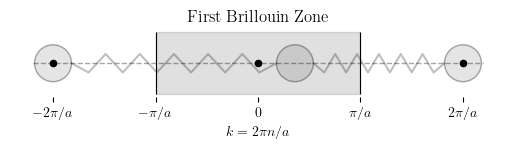

In [49]:
import math

def bz1_1d(a: float=1.0, n_min=-1, n_max=1,
  A=0.18,
  k=onp.pi / 2,
  omega=1.0,
  t=0.0,
):
  fig, ax = plt.subplots() # figsize=(8.5, 2.8)
  ns = onp.arange(n_min, n_max + 1)
  x_eq = ns * a
  bragg = 1 / 2 * (x_eq[1:] + x_eq[:-1])
  plot_lattice_1d(ax, x_eq, (n_min - 0.1) * a, (n_max + 0.1) * a, atom_alpha=1.0)
  ymin, ymax = -0.15 * a, 0.15 * a
  ax.vlines(bragg, ymin, ymax, color="k", alpha=1.0, linewidth=0.8)
  rect = Rectangle((bragg[0], ymin), bragg[-1]-bragg[0], ymax-ymin, alpha=0.12, color="k")
  ax.add_patch(rect)

  u = A * a * onp.cos(k * x_eq - omega * t)
  x_disp = x_eq + u

  mass_radius = 0.09 * a
  for x0, x1 in zip(x_disp[:-1], x_disp[1:]):
    sx, sy = spring_points(
      x0,
      x1,
      y=0.0,
      amp=0.045 * a,
      coils=6,
      margin=mass_radius,
    )
    ax.plot(sx, sy, linewidth=1.5, color="k", alpha=0.25)

  for i, (x0, x1) in enumerate(zip(x_eq, x_disp)):
    circ = Circle((x1, 0), radius=mass_radius, fill=True, color="k", alpha=0.1)
    ax.add_patch(circ)
    edge = Circle((x1, 0), radius=mass_radius, fill=False, color="k", linewidth=1.0, alpha=0.25)
    ax.add_patch(edge)


  # ax.axhspan(ymin, ymax, xmin=bragg[0], xmax=bragg[-1], alpha=0.12, color="k")
  ax.set(aspect='equal', yticks=[])
  bragg_bcast = onp.concat((bragg, onp.ones(1)))
  ticks = onp.stack((x_eq, bragg_bcast), axis=1).flatten()[:-1]
  ax.set_xticks(ticks.tolist())
  ax.set_xticklabels([r'$-2\pi/a$', r'$-\pi/a$', r'$0$', r'$\pi/a$', r'$2\pi/a$'])
  ax.set_title('First Brillouin Zone')
  plt.box(False)
  # ax.set_xticklabels([])
  ax.set_xlabel(r'$k=2\pi n/a$')
  return fig

fig = bz1_1d()
fig.savefig("first_brillouin_zone_1d.pdf", bbox_inches="tight", dpi=300)

plt.show()

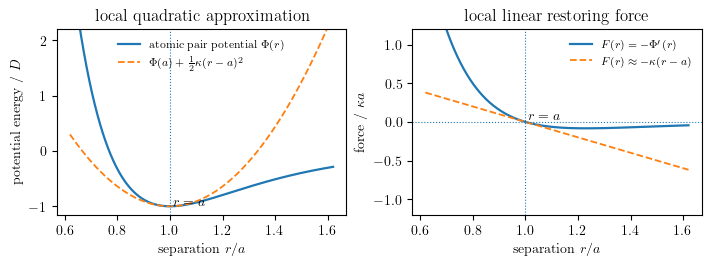

In [ ]:
import numpy as onp
import matplotlib.pyplot as plt

def plot_atomic_harmonic_approx(a=1.0, D=1.0, alpha=3.0):
  """
  Paper-ready schematic:
  left  = generic interatomic pair potential and harmonic approximation
  right = corresponding force and linear restoring-force approximation
  """
  kappa = 2 * D * alpha**2

  r = onp.linspace(0.62 * a, 1.62 * a, 800)
  Phi = D * ((1 - onp.exp(-alpha * (r - a)))**2 - 1)
  Phi_harm = -D + 0.5 * kappa * (r - a) ** 2

  F = -2 * D * alpha * onp.exp(-alpha * (r - a)) * (1 - onp.exp(-alpha * (r - a)))
  F_lin = -kappa * (r - a)

  fig, axs = plt.subplots(1, 2, figsize=(7.0, 2.55), constrained_layout=True)

  ax = axs[0]
  ax.plot(r / a, Phi / D, linewidth=1.6, label=r"atomic pair potential $\Phi(r)$")
  ax.plot(r / a, Phi_harm / D, "--", linewidth=1.3,
          label=r"$\Phi(a)+\frac12\kappa(r-a)^2$")
  ax.axvline(1, linewidth=0.8, linestyle=":")
  ax.text(1.01, -0.92, r"$r=a$", ha="left", va="center", fontsize=10)
  ax.set(
    xlabel=r"separation $r/a$",
    ylabel=r"potential energy / $D$",
    title=r"local quadratic approximation",
    ylim=(-1.15, 2.2),
  )
  ax.legend(frameon=False, fontsize=8)

  ax = axs[1]
  ax.plot(r / a, F / (kappa * a), linewidth=1.6, label=r"$F(r)=-\Phi'(r)$")
  ax.plot(r / a, F_lin / (kappa * a), "--", linewidth=1.3,
          label=r"$F(r)\approx-\kappa(r-a)$")
  ax.axhline(0, linewidth=0.8, linestyle=":")
  ax.axvline(1, linewidth=0.8, linestyle=":")
  ax.text(1.01, 0.08, r"$r=a$", ha="left", va="center", fontsize=10)
  ax.set(
    xlabel=r"separation $r/a$",
    ylabel=r"force / $\kappa a$",
    title=r"local linear restoring force",
    ylim=(-1.2, 1.2),
  )
  ax.legend(frameon=False, fontsize=8)

  return fig, axs

fig, axs = plot_atomic_harmonic_approx()
fig.savefig("atomic_harmonic_approximation.pdf", bbox_inches="tight", dpi=300)
fig.savefig("atomic_harmonic_approximation.png", bbox_inches="tight", dpi=300)
plt.show()